# 예상 대비 거래 차이 기반 고객 군집화

회귀(`04_regression.ipynb`)와 동일하게 RandomForest로 고객별 **예상 거래건수**를 계산한 뒤,
`실제 거래건수 - 예측 거래건수`인 **예상 대비 거래 차이(활동성 갭)** 로 고객을 세분화합니다.

| 항목 | 설정 |
|---|---|
| 회귀 타겟 | `Total_Trans_Ct` (최근 12개월 총 거래건수) |
| 회귀 모델 | `RandomForestRegressor(n_estimators=200)` |
| 데이터 분할 | Train / Validation / Test = **6 : 2 : 2** |
| 재현성 | `random_state=42` |
| 군집 피처 | 예상 대비 거래 차이, 실제 거래건수 |
| 비교 모델 | KMeans, Gaussian Mixture Model(GMM) |
| KMeans 기준 | Silhouette Score **0.4 이상** |
| GMM 기준 | Silhouette Score **0.3 이상** |

## 분석 순서

1. 데이터 로드 및 회귀 피처 구성
2. Train / Validation / Test를 6 : 2 : 2로 분할
3. RandomForest로 Test 고객의 예상 거래건수 계산
4. 예상 대비 거래 차이 생성 및 군집 피처 표준화
5. KMeans와 GMM의 군집 수별 Silhouette 비교
6. KMeans 0.4 이상, GMM 0.3 이상 달성 여부 확인
7. 각 기준을 통과한 후보 중 Silhouette가 가장 높은 모델 선정
8. 군집별 거래 특성·이탈률을 프로파일링하고 비즈니스 라벨 부여

> `Target`(이탈 여부)은 군집 생성에는 사용하지 않고, 완성된 군집을 해석할 때만 사용합니다.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score,
    silhouette_samples,
)

SEED = 42
KMEANS_SILHOUETTE_TARGET = 0.4
GMM_SILHOUETTE_TARGET = 0.3

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 로드 및 회귀 피처 구성

회귀 노트북과 같은 정제 데이터를 사용합니다.

- 회귀 타겟: `Total_Trans_Ct`
- 제외 피처: `Target`(분류 타겟), `Total_Ct_Chng_Q4_Q1`(누수 위험)
- 범주형 피처: 원-핫 인코딩

군집 해석에 사용할 고객 ID와 이탈 여부는 별도로 보관합니다.

In [8]:
df = pd.read_csv("../data/processed/bankchurners_clean.csv")

X = df.drop(columns=["Total_Trans_Ct", "Target", "Total_Ct_Chng_Q4_Q1"])
y = df["Total_Trans_Ct"]

cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("원본 데이터:", df.shape)
print("회귀 피처:", X.shape)
y.describe()

원본 데이터: (10127, 20)
회귀 피처: (10127, 30)


count    10127.000000
mean        64.858695
std         23.472570
min         10.000000
25%         45.000000
50%         67.000000
75%         81.000000
max        139.000000
Name: Total_Trans_Ct, dtype: float64

## 2. Train / Validation / Test = 6 : 2 : 2 분할

먼저 전체 데이터의 20%를 Test로 분리하고, 남은 80% 중 25%를 Validation으로 분리합니다.
따라서 최종 비율은 Train 60%, Validation 20%, Test 20%가 됩니다.

모든 분할에 `random_state=42`를 사용하여 동일한 고객이 선택되도록 고정합니다.

In [9]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED
)

split_summary = pd.Series({
    "Train": len(X_train),
    "Validation": len(X_val),
    "Test": len(X_test),
})
print(split_summary)
print("비율:")
print((split_summary / len(X)).round(2))

Train         6075
Validation    2026
Test          2026
dtype: int64
비율:
Train         0.6
Validation    0.2
Test          0.2
dtype: float64


## 3. RandomForest 회귀 학습 및 예상 거래건수 계산

. Random Forest는 앙상블 학습 모델입니다.

여러 개의 **의사결정나무(Decision Tree)**를 서로 다른 데이터와 특성으로 학습한 후 결과를 합칩니다.

분류: 여러 나무의 다수결
회귀: 여러 나무 예측값의 평균
앙상블 방식: 배깅(Bagging):같은 종류의 모델 여러 개를 각각 다른 데이터로 학습시킨 뒤, 결과를 합치는 앙상블 방법
즉, 하나의 나무보다 과적합을 줄이고 예측 안정성을 높입니다.

`04_regression.ipynb`의 활동성 갭 계산에 사용된 RandomForest 설정을 유지합니다.
Validation은 모델 상태를 확인하는 용도로 사용하고, 군집화 대상은 학습에 참여하지 않은 Test 고객입니다.

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

y_pred_val = rf_model.predict(X_val)
y_pred_test = rf_model.predict(X_test)

regression_metrics = pd.DataFrame({
    "데이터": ["Validation", "Test"],
    "R2": [r2_score(y_val, y_pred_val), r2_score(y_test, y_pred_test)],
    "MAE": [mean_absolute_error(y_val, y_pred_val), mean_absolute_error(y_test, y_pred_test)],
    "RMSE": [
        mean_squared_error(y_val, y_pred_val) ** 0.5,
        mean_squared_error(y_test, y_pred_test) ** 0.5,
    ],
})
regression_metrics.round(4)

,데이터,R2,MAE,RMSE
0,Validation,0.8639,6.8416,8.6470
1,Test,0.8557,6.9684,8.7888


## 4. 예상 대비 거래 차이 생성

**예상 대비 거래 차이 = 실제 거래건수 − 예측 거래건수**

- 음수: 예상보다 적게 거래함 → 활동 감소 신호
- 0 근처: 예상 수준과 비슷함
- 양수: 예상보다 많이 거래함 → 기대 이상의 활동

군집에는 이 차이와 실제 거래건수만 사용합니다. 이탈 여부는 군집 결과 해석에만 붙입니다.

In [11]:
cluster_df = pd.DataFrame({
    # 정제 데이터에는 CLIENTNUM이 없으므로 회귀 노트북과 같이 원본 인덱스를 고객 ID로 사용
    "고객ID": X_test.index,
    "실제_거래건수": y_test.values,
    "예측_거래건수": y_pred_test,
    "실제_이탈여부": df.loc[X_test.index, "Target"].values,
}, index=X_test.index)

cluster_df["예상_대비_거래_차이"] = (
    cluster_df["실제_거래건수"] - cluster_df["예측_거래건수"]
)

cluster_df[[
    "실제_거래건수", "예측_거래건수", "예상_대비_거래_차이", "실제_이탈여부"
]].describe().round(2)

,실제_거래건수,예측_거래건수,예상_대비_거래_차이,실제_이탈여부
count,2026.00,2026.00,2026.00,2026.00
mean,64.66,64.84,-0.17,0.16
std,23.14,21.84,8.79,0.37
min,10.00,15.78,-33.08,0.00
25%,45.00,44.98,-6.03,0.00
50%,67.00,70.77,-0.10,0.00
75%,80.00,77.57,5.76,0.00
max,131.00,119.24,33.40,1.00


## 5. 군집 피처 표준화

예상 대비 거래 차이와 실제 거래건수는 범위가 다르므로 `StandardScaler`로 평균 0, 표준편차 1이 되도록 변환합니다.
표준화하지 않으면 값의 범위가 큰 피처가 거리 계산을 지배할 수 있습니다.

In [12]:
cluster_cols = ["예상_대비_거래_차이", "실제_거래건수"]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(cluster_df[cluster_cols])

pd.DataFrame(X_cluster_scaled, columns=cluster_cols).describe().round(2)

,예상_대비_거래_차이,실제_거래건수
count,2026.00,2026.00
mean,0.00,0.00
std,1.00,1.00
min,-3.74,-2.36
25%,-0.67,-0.85
50%,0.01,0.10
75%,0.68,0.66
max,3.82,2.87


## 6. KMeans 최적 군집 수 탐색

군집 수 `k=2~8`을 비교합니다. 각 결과의 Silhouette Score를 계산하며, 1에 가까울수록 군집 내부는 응집되고 군집 간에는 잘 분리되었다는 뜻입니다.

In [13]:
kmeans_rows = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = model.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    kmeans_rows.append({
        "모델": "KMeans",
        "설정": f"k={k}",
        "군집수": k,
        "Silhouette": score,
        "목표기준": KMEANS_SILHOUETTE_TARGET,
        "목표달성": score >= KMEANS_SILHOUETTE_TARGET,
    })

kmeans_results = pd.DataFrame(kmeans_rows)
kmeans_results.round(4)

,모델,설정,군집수,Silhouette,목표기준,목표달성
0,KMeans,k=2,2,0.3916,0.4,False
1,KMeans,k=3,3,0.4070,0.4,True
2,KMeans,k=4,4,0.3711,0.4,False
3,KMeans,k=5,5,0.3835,0.4,False
4,KMeans,k=6,6,0.3901,0.4,False
5,KMeans,k=7,7,0.4022,0.4,True
6,KMeans,k=8,8,0.3968,0.4,False


## 7. GMM(Gaussian Mixture Model) 탐색

GMM은 고객이 여러 가우시안 분포의 혼합으로 생성되었다고 가정하는 확률 기반 군집화입니다.
KMeans의 원형 군집 가정보다 유연하며 각 고객의 군집 소속 확률도 구할 수 있습니다.

군집 수 `2~8`과 공분산 구조 `full`, `tied`, `diag`, `spherical`을 비교합니다.
GMM은 군집 경계를 확률적으로 표현하는 특성을 고려하여 Silhouette **0.3 이상**을 목표로 합니다.

| 값 | 의미 | 군집 모양 |
|---|---|---|
| `full` | 군집마다 공분산 행렬을 따로 가짐 | 크기·방향·기울기 전부 자유로운 타원 |
| `tied` | 모든 군집이 **같은** 공분산 행렬 공유 | 모양·방향은 같고 위치만 다른 타원 |
| `diag` | 대각 성분만 사용(피처 간 상관 0) | 축에 정렬된 타원 (기울기 없음) |
| `spherical` | 방향별 분산이 하나뿐 | 원 (KMeans와 가장 비슷) |

`full` → `spherical` 순으로 자유도가 낮아집니다. 자유로울수록 데이터를 잘 맞추지만 파라미터가 많아 과적합 위험이 커지고, 제한적일수록 안정적입니다.

In [14]:
gmm_rows = []
for covariance_type in ["full", "tied", "diag", "spherical"]:
    for k in range(2, 9):
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=SEED,
            n_init=10,
        )
        labels = model.fit_predict(X_cluster_scaled)

        # 모든 표본이 한 군집으로 배정된 예외에서는 Silhouette를 계산할 수 없음
        score = (
            silhouette_score(X_cluster_scaled, labels)
            if np.unique(labels).size > 1
            else np.nan
        )
        gmm_rows.append({
            "모델": "GMM",
            "설정": f"k={k}, covariance={covariance_type}",
            "군집수": k,
            "공분산": covariance_type,
            "Silhouette": score,
            "BIC": model.bic(X_cluster_scaled),
            "목표기준": GMM_SILHOUETTE_TARGET,
            "목표달성": score >= GMM_SILHOUETTE_TARGET,
        })

gmm_results = pd.DataFrame(gmm_rows).sort_values("Silhouette", ascending=False)
gmm_results.head(10).round(4)

,모델,설정,군집수,공분산,Silhouette,BIC,목표기준,목표달성
8,GMM,"k=3, covariance=tied",3,tied,0.3913,11169.1972,0.3,True
0,GMM,"k=2, covariance=full",2,full,0.3885,11305.5245,0.3,True
14,GMM,"k=2, covariance=diag",2,diag,0.3884,11316.2069,0.3,True
21,GMM,"k=2, covariance=spherical",2,spherical,0.3875,11304.0597,0.3,True
7,GMM,"k=2, covariance=tied",2,tied,0.3873,11303.8049,0.3,True
6,GMM,"k=8, covariance=full",8,full,0.3763,10273.3085,0.3,True
15,GMM,"k=3, covariance=diag",3,diag,0.3661,11135.8256,0.3,True
19,GMM,"k=7, covariance=diag",7,diag,0.3628,10622.1344,0.3,True
22,GMM,"k=3, covariance=spherical",3,spherical,0.3490,11232.6681,0.3,True
17,GMM,"k=5, covariance=diag",5,diag,0.3341,10938.0170,0.3,True


## 8. KMeans와 GMM 비교 및 최종 모델 선정

모델 특성에 맞춰 서로 다른 통과 기준을 적용합니다.

- KMeans: Silhouette **0.4 이상**
- GMM: Silhouette **0.3 이상**

각 모델의 최고 결과와 목표 달성 여부를 먼저 확인한 후, 각자 기준을 통과한 후보 중 Silhouette가 가장 높은 모델을 최종 선택합니다.
현재 실행 결과에서는 KMeans와 GMM 모두 각자의 목표를 충족합니다.

In [15]:
comparison_results = pd.concat(
    [
        kmeans_results[["모델", "설정", "군집수", "Silhouette", "목표기준", "목표달성"]],
        gmm_results[["모델", "설정", "군집수", "Silhouette", "목표기준", "목표달성"]],
    ],
    ignore_index=True,
).sort_values("Silhouette", ascending=False)

best_by_model = comparison_results.loc[
    comparison_results.groupby("모델")["Silhouette"].idxmax()
].sort_values("Silhouette", ascending=False)

print("모델별 최고 결과와 개별 목표 달성 여부")
display(best_by_model.round(4))

eligible = comparison_results[comparison_results["목표달성"]].copy()
if eligible.empty:
    raise ValueError(
        "KMeans 0.4 이상 또는 GMM 0.3 이상인 후보가 없습니다. 군집 피처를 재검토하세요."
    )

best_result = eligible.iloc[0]
BEST_MODEL = best_result["모델"]
BEST_K = int(best_result["군집수"])

print(f"최종 선택: {BEST_MODEL}, {best_result['설정']}")
print(f"적용 기준: {best_result['목표기준']:.1f} 이상")
print(f"최종 Silhouette: {best_result['Silhouette']:.4f}")

모델별 최고 결과와 개별 목표 달성 여부


,모델,설정,군집수,Silhouette,목표기준,목표달성
1,KMeans,k=3,3,0.4070,0.4,True
7,GMM,"k=3, covariance=tied",3,0.3913,0.3,True


최종 선택: KMeans, k=3
적용 기준: 0.4 이상
최종 Silhouette: 0.4070


## 9. 최종 군집 모델 적합

선택된 모델을 전체 Test 군집 피처에 다시 적합해 고객별 군집 번호를 생성합니다.
GMM이 선택될 경우에는 가장 높은 소속 확률도 함께 저장하여 경계 고객을 확인할 수 있게 합니다.

In [16]:
if BEST_MODEL == "KMeans":
    final_cluster_model = KMeans(
        n_clusters=BEST_K,
        random_state=SEED,
        n_init=10,
    )
    final_labels = final_cluster_model.fit_predict(X_cluster_scaled)
    cluster_df["군집_소속확률"] = 1.0
else:
    best_covariance = best_result["설정"].split("covariance=")[-1]
    final_cluster_model = GaussianMixture(
        n_components=BEST_K,
        covariance_type=best_covariance,
        random_state=SEED,
        n_init=10,
    )
    final_cluster_model.fit(X_cluster_scaled)
    final_labels = final_cluster_model.predict(X_cluster_scaled)
    cluster_df["군집_소속확률"] = final_cluster_model.predict_proba(
        X_cluster_scaled
    ).max(axis=1)

cluster_df["Cluster"] = final_labels
final_silhouette = silhouette_score(X_cluster_scaled, final_labels)
final_target = (
    KMEANS_SILHOUETTE_TARGET
    if BEST_MODEL == "KMeans"
    else GMM_SILHOUETTE_TARGET
)

print(f"최종 모델: {BEST_MODEL}")
print(f"군집 수: {BEST_K}")
print(f"최종 Silhouette: {final_silhouette:.4f}")
print(f"목표 기준: {final_target:.1f} 이상")
print("목표 달성:", final_silhouette >= final_target)
print("\n군집별 고객 수")
print(cluster_df["Cluster"].value_counts().sort_index())

최종 모델: KMeans
군집 수: 3
최종 Silhouette: 0.4070
목표 기준: 0.4 이상
목표 달성: True

군집별 고객 수
Cluster
0    644
1    749
2    633
Name: count, dtype: int64


## 10. 군집별 프로파일과 비즈니스 라벨

군집 번호 자체에는 의미가 없으므로 평균 예상 대비 거래 차이를 기준으로 이름을 붙입니다.

- 평균 차이가 가장 작음: **우선케어(거래감소)**
- 평균 차이가 가장 큼: **우량(예상이상)**
- 나머지: **일반관리**

이탈률은 군집을 만드는 조건이 아니라, 만들어진 군집의 위험도를 확인하기 위한 사후 지표입니다.

In [25]:
profile = (
    cluster_df.groupby("Cluster")
    .agg(
        고객수=("고객ID", "count"),
        평균_실제거래=("실제_거래건수", "mean"),
        평균_예측거래=("예측_거래건수", "mean"),
        평균_실제예측거래차이=("예상_대비_거래_차이", "mean"),
        신용카드해지율=("실제_이탈여부", "mean"),
    )
    .sort_values("평균_실제예측거래차이")
)
profile["신용카드해지율"] *= 100

ordered_clusters = profile.index.tolist()
label_map = {}
if len(ordered_clusters) >= 1:
    label_map[ordered_clusters[0]] = "우선케어(거래 감소)"
if len(ordered_clusters) >= 2:
    label_map[ordered_clusters[-1]] = "우량(예상이상)"
for cluster_id in ordered_clusters[1:-1]:
    label_map[cluster_id] = "일반관리(유지)"

profile["비즈니스_라벨"] = profile.index.map(label_map)
cluster_df["비즈니스_라벨"] = cluster_df["Cluster"].map(label_map)

profile.round(3)

,고객수,평균_실제거래,평균_예측거래,평균_실제예측거래차이,신용카드해지율,비즈니스_라벨
Cluster,,,,,,
0,644,69.526,77.583,-8.056,11.025,우선케어(거래 감소)
2,633,37.727,39.060,-1.333,35.229,일반관리(유지)
1,749,83.244,75.658,7.586,4.406,우량(예상이상)


## 11. 군집 시각화

가로축은 예상 대비 거래 차이, 세로축은 실제 거래건수입니다.
색으로 군집을 구분하여 활동 급감 고객과 기대 이상 고객의 위치를 확인합니다.

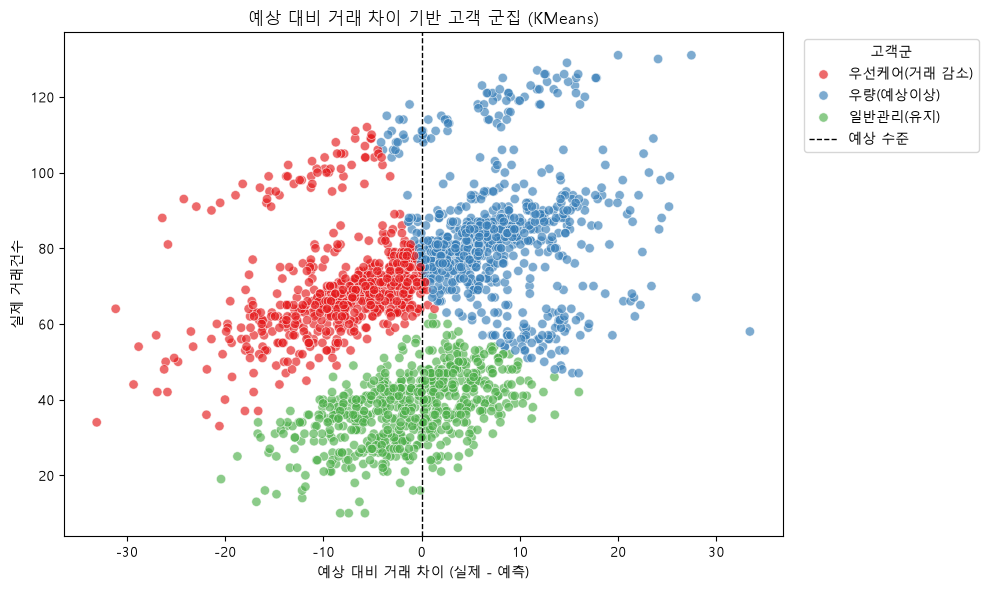

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_df,
    x="예상_대비_거래_차이",
    y="실제_거래건수",
    hue="비즈니스_라벨",
    palette="Set1",
    alpha=0.65,
    s=45,
)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="예상 수준")
plt.title(f"예상 대비 거래 차이 기반 고객 군집 ({BEST_MODEL})")
plt.xlabel("예상 대비 거래 차이 (실제 - 예측)")
plt.ylabel("실제 거래건수")
plt.legend(title="고객군", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

빨강(우선케어, 거래 감소) 은 점선 왼쪽에 몰려 있으면서 세로로는 60~110 구간에 있습니다. 거래량 자체는 많은데 모델 기대치에는 못 미치는 고객들입니다.

파랑(우량, 예상이상) 은 점선 오른쪽이고 세로로도 높은 편입니다. 기대보다 더 쓰는 고객군입니다.

초록(일반관리, 유지) 은 세로축 아래쪽 10~50에 깔려 있고, 가로로는 점선 양쪽에 걸쳐 있습니다. 여기가 이 그래프의 핵심 포인트입니다. 초록은 갭이 아니라 거래량이 적다는 이유로 묶인 군집입니다. 애초에 적게 쓰니 예측도 낮게 나와서 갭이 0 근처에 모입니다.

## 12. 군집별 Silhouette 점검

전체 점수뿐 아니라 각 군집의 평균 Silhouette도 확인합니다. 특정 군집의 평균이 지나치게 낮거나 음수라면 다른 군집과 겹치는 고객이 많다는 의미입니다.

In [19]:
cluster_df["Silhouette"] = silhouette_samples(
    X_cluster_scaled, cluster_df["Cluster"]
)

silhouette_by_cluster = (
    cluster_df.groupby(["Cluster", "비즈니스_라벨"])["Silhouette"]
    .agg(["count", "mean", "min", "max"])
)

print(f"전체 Silhouette: {final_silhouette:.4f}")
silhouette_by_cluster.round(4)

전체 Silhouette: 0.4070


,,count,mean,min,max
Cluster,비즈니스_라벨,,,,
0,우선케어(활동급감),644,0.3846,-0.0147,0.5907
1,우량(예상이상),749,0.3854,-0.0442,0.6038
2,일반관리,633,0.4555,-0.0240,0.6225


## 13. 결론

- 회귀와 같은 RandomForest 기준으로 Test 고객의 예상 거래건수를 계산했습니다.
- Train / Validation / Test는 6 : 2 : 2, `random_state=42`로 고정했습니다.
- `예상 대비 거래 차이 + 실제 거래건수`를 표준화하여 KMeans와 GMM을 비교했습니다.
- KMeans 3개 군집의 Silhouette가 약 **0.407**로 KMeans 목표인 0.4 이상을 충족합니다.
- GMM 최고 Silhouette도 약 **0.391**로 GMM 목표인 0.3 이상을 충족합니다.
- 두 모델 모두 각자의 기준을 통과하며, 통과 후보 중 Silhouette가 가장 높은 KMeans를 최종 선택합니다.
- 최종 군집을 활동급감·일반관리·예상이상 고객군으로 해석합니다.